In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import lstsq
from sklearn.model_selection import train_test_split
import cvxpy as cp

In [52]:
def solve_inner_2R2C(C, q_hp, delta_T_i, delta_T_a, delta_T_i_m, q_solar, 
                     SPC_sum, DHW_sum,
                Q_DHW_estimate, q_max, delta_t):
    """Solve inner CVXPY problem for a given C and return parameters + metrics."""
    N = len(delta_T_i)
    Q_sc = np.sum(q_hp) - Q_DHW_estimate - SPC_sum + DHW_sum

    # CVXPY variables
    a = cp.Variable(pos=True)
    b = cp.Variable(pos=True)
    w_s = cp.Variable(nonneg=True)
    #w_w = cp.Variable(nonneg=True)
    w = cp.Variable()
    e = cp.Variable()
    z = cp.Variable(N, nonneg=True)
    u = cp.Variable(N)
    q_hat = cp.Variable(N)

    # Expression
    expr = (delta_T_a * a * delta_t + delta_T_i_m * b * delta_t + q_hat + w_s * 
            q_solar + w * np.ones (N) * delta_t)

    # Constraints
    constraints = [
        cp.sum(q_hat) - Q_sc == e,
        delta_T_i + u == expr / C,
        q_hat >= 0,
        #q_hat <= q_hp + z,
        q_hat <= q_max,
        a >= 1 / 25,
        b >= 1 / 100
    ]

    # Objective weights
    '''
    phi_e = 0.1
    phi_z = 0.001
    phi_u = 2000
    objective = cp.Minimize(
        phi_e * e ** 2 +
        phi_z * cp.norm2(z) +
        phi_u * cp.norm2(u),
    )
    '''
    ph_q = 100
    phi_e = 0.1
    phi_z = 0.001
    phi_u = 200
    objective = cp.Minimize(
        ph_q * cp.norm1(q_hat-q_hp) * delta_t + 
        phi_e * e ** 2 * delta_t +
        phi_z * cp.norm2(z) * delta_t +
        phi_u * cp.norm2(u) * delta_t +
        phi_z * cp.maximum(0, -(q_hat + z)).sum() * delta_t
    )

    prob = cp.Problem(objective, constraints)
    _ = prob.solve(solver=cp.GUROBI, verbose=False)

    # Extract values
    R_a = 1 / a.value
    R_m = 1 / b.value
    ws_val = w_s.value
    #ww_val = w_w.value
    w_val = w.value
    q_hat_val = q_hat.value

    # RMSE for dTi (u)
    rmse_dTi = np.sqrt(np.mean(u.value ** 2))

    # RMSE for q_hat vs q_hp
    rmse_q = np.sqrt(np.mean((q_hat.value - q_hp * delta_t) ** 2))

    return R_a, R_m, ws_val, w_val, rmse_q, rmse_dTi, q_hat_val, Q_sc

In [53]:
df_data = pd.read_parquet("../training_data/initial_dataset.parquet")
df_train_detached = pd.read_parquet(
    "../training_data/data_detached_with_weather.parquet")
type(df_data)
type(df_train_detached)
df_train_detached

,Property_ID,Timestamp,half-hour,Boiler_Energy_Output,Circulation_Pump_Energy_Consumed,Heat_Pump_Energy_Output,Whole_System_Energy_Consumed,External_Air_Temperature,Heat_Pump_Heating_Flow_Temperature,Heat_Pump_Return_Temperature,...,Postcode,Time,Temperature,FeelsLike,Humidity,Dew,Precipitation,SolarRadiation,SolarEnergy,Windspeed
0,EOH0279,2020-10-26 00:00:00,00:00:00,NaN,0.000,0.000,0.008,9.38,23.14,23.35,...,EH22,00:00:00,8.90,6.10,79.75,5.6,0.154,0.0,0.0,19.30
1,EOH1703,2020-10-26 00:00:00,00:00:00,NaN,0.013,0.242,0.078,7.08,25.04,24.04,...,NE15,00:00:00,7.00,4.30,81.71,4.1,0.170,0.0,0.0,14.30
2,EOH1703,2020-10-26 00:30:00,00:30:00,NaN,0.029,0.622,0.212,6.83,25.43,24.23,...,NE15,00:30:00,6.95,4.05,81.93,4.1,0.085,0.0,0.0,15.85
3,EOH0279,2020-10-26 00:30:00,00:30:00,NaN,0.000,0.000,0.019,9.33,22.54,22.80,...,EH22,00:30:00,8.85,6.30,79.94,5.6,0.077,0.0,0.0,17.00
4,EOH0279,2020-10-26 01:00:00,01:00:00,NaN,0.000,2.730,0.967,9.21,35.27,30.93,...,EH22,01:00:00,8.80,6.50,80.13,5.6,0.000,0.0,0.0,14.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505054,EOH3154,2023-09-29 00:00:00,00:00:00,NaN,0.000,44801.768,14989.282,12.44,18.87,50.46,...,EH15,00:00:00,12.80,12.80,90.62,11.3,0.333,0.0,0.0,16.00
505055,EOH1637,2023-09-29 00:00:00,00:00:00,NaN,203.311,43996.381,13830.005,12.17,16.70,16.53,...,PH7,00:00:00,13.20,13.20,86.43,11.0,0.004,0.0,0.0,17.00
505056,EOH2329,2023-09-29 00:00:00,00:00:00,NaN,31.139,14128.100,5775.602,12.44,24.80,26.31,...,EH4,00:00:00,12.90,12.90,90.75,11.4,0.378,0.0,0.0,15.00
505057,EOH2675,2023-09-29 00:00:00,00:00:00,NaN,212.928,59675.471,19247.887,12.44,14.82,14.85,...,EH9,00:00:00,13.00,13.00,93.04,11.9,0.024,0.0,0.0,24.30


In [54]:
unique_ids[5]

'EOH2675'

In [55]:
unique_ids = df_train_detached["Property_ID"].unique()
id_use = unique_ids[5]
df_house = pd.read_csv('../training_data/home_characteristics.csv')

# List of columns to check for missingness
cols = [
    "Bedrooms", "Floor_Height", "Habitable_Rooms", "House_Age",
    "House_Form", "No_Storeys", "No_Underfloor",
    "Total_Floor_Area", "Wall_Type", "MCS_DHWAnnual","HP_Size_kW"
]

df_house_train = {}
#for id_use in unique_ids:
df_house_train[id_use] = df_house[df_house["Property_ID"] == id_use]

In [56]:
df_train_detached[
        df_train_detached["Property_ID"] == id_use].copy()

,Property_ID,Timestamp,half-hour,Boiler_Energy_Output,Circulation_Pump_Energy_Consumed,Heat_Pump_Energy_Output,Whole_System_Energy_Consumed,External_Air_Temperature,Heat_Pump_Heating_Flow_Temperature,Heat_Pump_Return_Temperature,...,Postcode,Time,Temperature,FeelsLike,Humidity,Dew,Precipitation,SolarRadiation,SolarEnergy,Windspeed
2892,EOH2675,2020-11-12 13:00:00,13:00:00,NaN,0.000,0.678,0.173,9.78,38.61,36.12,...,EH9,13:00:00,9.90,6.9,75.670,5.80,0.0000,144.0,0.50,24.10
2896,EOH2675,2020-11-12 13:30:00,13:30:00,NaN,0.000,1.497,0.390,10.01,35.50,34.90,...,EH9,13:30:00,9.55,6.5,77.755,5.85,0.0000,112.0,0.40,23.15
2903,EOH2675,2020-11-12 14:00:00,14:00:00,NaN,0.000,4.319,1.099,10.27,34.98,31.74,...,EH9,14:00:00,9.20,6.1,79.840,5.90,0.0000,80.0,0.30,22.20
2911,EOH2675,2020-11-12 14:30:00,14:30:00,NaN,0.000,5.880,1.470,10.42,33.72,31.56,...,EH9,14:30:00,9.20,6.4,79.900,5.90,0.0000,67.5,0.25,19.30
2915,EOH2675,2020-11-12 15:00:00,15:00:00,NaN,0.000,8.053,2.043,10.41,35.83,33.70,...,EH9,15:00:00,9.20,6.7,79.960,5.90,0.0000,55.0,0.20,16.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505016,EOH2675,2023-09-28 22:00:00,22:00:00,NaN,212.928,59675.471,19247.864,13.39,14.86,15.03,...,EH9,22:00:00,14.00,14.0,82.040,11.00,0.0110,0.0,0.00,25.40
505024,EOH2675,2023-09-28 22:30:00,22:30:00,NaN,212.928,59675.471,19247.872,13.08,14.86,14.98,...,EH9,22:30:00,14.00,14.0,82.225,11.00,0.0400,0.0,0.00,24.70
505038,EOH2675,2023-09-28 23:00:00,23:00:00,NaN,212.928,59675.471,19247.879,12.77,14.86,14.94,...,EH9,23:00:00,14.00,14.0,82.410,11.00,0.0690,0.0,0.00,24.00
505050,EOH2675,2023-09-28 23:30:00,23:30:00,NaN,212.928,59675.471,19247.885,12.44,14.84,14.89,...,EH9,23:30:00,13.50,13.5,87.725,11.45,0.0465,0.0,0.00,24.15


In [57]:
t_step = 30  # minutes
delta_t = t_step / 60

trained_params = pd.DataFrame(index=["Floor Area", "No_Storeys", "Wall_Type",
                                     "C", "R_a", "R_m", "w_s", "w_w", "w",
                                     "Q_hat", "Q_sc", "rmse_dTi",
                                     "rmse_q_hp"])

df_single = df_train_detached[df_train_detached["Property_ID"] == id_use].copy()
df_single = df_single.set_index('Timestamp')

#time range for indexing only
t_start = pd.to_datetime("2022 01 01 00:00:00")
t_mid_end = pd.to_datetime("2022 5 30 23:59:59")
t_mid_start = pd.to_datetime("2022 08 31 00:00:00")
t_end = pd.to_datetime("2022 12 31 23:59:59")
df_index = df_single[df_single.index >= t_start]
df_index = df_index[df_index.index <= t_end]
df_index = df_index[
    (df_index.index <= t_mid_end) | (df_index.index >= t_mid_start)]

# Create time index for q_hat arrays
time_index = df_index.index[:-1]
df_q_id = pd.DataFrame(index=time_index)


# ---- initialize and clean data ---------
wall = df_house_train[id_use].Wall_Type.to_string()
storeys = df_house_train[id_use].No_Storeys.to_string()
floor_area = df_house_train[id_use].Total_Floor_Area.to_string()

df_single = df_train_detached[
    df_train_detached["Property_ID"] == id_use].copy()

#re-adjust Heat Pump Diff and add temp differences
df_single["Heat_Pump_Energy_Output_Diff"] = df_single[
    "Heat_Pump_Energy_Output"].diff()
df_single["Internal_Temperature_Diff"] = df_single[
    "Internal_Air_Temperature"].diff()
df_single["Internal_Ambient_Temperature_Diff"] = \
    (df_single["External_Air_Temperature"] -
     df_single["Internal_Air_Temperature"])


# mass temp assumed to be lagged moving average
window_steps = 15   # ← easily adjust this!

temps = df_single["Internal_Air_Temperature"]

# trailing moving average (includes the current step + the previous window_steps−1)
df_single["Mass_Temperature"] = (
    temps
    .rolling(window=window_steps, min_periods=window_steps)  # require full window
    .mean()
)


# 1. Drop columns with almost all missing data (e.g., more than 90% missing)
threshold = 0.90 * len(df_single)
df_single_cleaned = df_single.dropna(axis=1, thresh=threshold)
#print("Columns dropped due to high missing values:")
#print(df_single.columns.difference(df_single_cleaned.columns).tolist())

df_single = df_single_cleaned

#print("\nColumns remaining after dropping highly missing columns:")
#print(df_single.columns.tolist())

df_single = df_single.set_index('Timestamp')
df_single = df_single.sort_index()

# Apply interpolation with a limit of 4 (for 2 hours of half-hourly data)
numeric_cols = df_single.select_dtypes(include=['number']).columns
df_single_numeric_interpolated = df_single[numeric_cols].interpolate(
    method='time', limit=4, limit_direction='both')

df_single_interpolated = df_single.copy()
df_single_interpolated[numeric_cols] = df_single_numeric_interpolated

# After interpolation, drop rows that still contain NaN values (meaning they were missing for > 2 hours)
initial_rows = len(df_single_interpolated)
df_single_processed = df_single_interpolated.dropna()
rows_dropped_after_interpolation = initial_rows - len(df_single_processed)

#print(f"\nNumber of rows dropped after handling NA values (missing for >
# 2 hours): {rows_dropped_after_interpolation}")

# -----EXTRACT SUMMER DATA -------# 
df_heating_single = df_single_processed.copy()
#df_heating_single = [df_single_processed["External_Air_Temperature"]<=18]

# Time range
t_start = pd.to_datetime("2022-6-01 00:00:00")
t_end = pd.to_datetime("2022-08-30 23:59:00")
df_DHW = df_heating_single[
    (df_heating_single.index >= t_start) & (
                df_heating_single.index <= t_end)
    ].copy()

df_DHW.drop("Property_ID", axis=1, inplace=True)
df_DHW.drop("half-hour", axis=1, inplace=True)
df_DHW.drop("Date", axis=1, inplace=True)
df_DHW.drop("has_data", axis=1, inplace=True)

i = 24

df_numeric = df_DHW.select_dtypes(include='number')

# Resample and compute mean
df_resampled = df_numeric.resample(f'{i}h').mean()

df_DHW_only = df_resampled[
    df_resampled["Heat_Pump_Energy_Output_Diff"] <= 0.15]

DHW_sum = []
DHW_sum = df_DHW_only["Heat_Pump_Energy_Output_Diff"].sum() * 24

df_spc_only = df_resampled[
    df_resampled["Heat_Pump_Energy_Output_Diff"] > 0.15]
SPC_sum = df_spc_only["Heat_Pump_Energy_Output_Diff"].sum() * 24

# ------ Prepare Training Data ----------
df_heating_single = df_single_processed.copy()

#time range
t_start = pd.to_datetime("2022 01 01 00:00:00")
t_mid_end = pd.to_datetime("2022 5 30 23:59:59")
t_mid_start = pd.to_datetime("2022 08 31 00:00:00")
t_end = pd.to_datetime("2022 12 31 23:59:59")
df_heating_annual = df_heating_single[df_heating_single.index >= t_start]
df_heating_annual = df_heating_annual[df_heating_annual.index <= t_end]
df_heating_annual = df_heating_annual[
    (df_heating_annual.index <= t_mid_end) | (df_heating_annual
                                              .index >= t_mid_start)]

T_a = (df_heating_annual["External_Air_Temperature"].iloc[:-1].reset_index
       (drop=True).to_numpy())
T_i = (df_heating_annual["Internal_Air_Temperature"].iloc[:-1].reset_index
       (drop=True).to_numpy())
delta_T_a = (df_heating_annual["Internal_Ambient_Temperature_Diff"].iloc[:-1]
    .reset_index(drop=True).to_numpy())
delta_T_i = (df_heating_annual["Internal_Temperature_Diff"].iloc[1:]
             .reset_index(drop=True).to_numpy() / delta_t)
delta_T_i_m = (df_heating_annual["Mass_Temperature"].iloc[:-1]
             .reset_index(drop=True).to_numpy()-T_i)
q_hp = (df_heating_annual["Heat_Pump_Energy_Output_Diff"].iloc[:-1]
        .reset_index(drop=True).to_numpy())
q_solar = (df_heating_annual["SolarRadiation"].iloc[:-1].reset_index
           (drop=True).to_numpy())
v_wind = (df_heating_annual["Windspeed"].iloc[:-1].reset_index(drop=True)
          .to_numpy())

N = len(delta_T_i)

Q_DHW_estimate = df_house_train[id_use].MCS_DHWAnnual.to_numpy()
q_max = df_house_train[id_use].HP_Size_kW.to_numpy()

# Create time index for in the loop q_hat arrays
time_index = df_heating_annual.index[:-1]
df_q_results = pd.DataFrame(index=time_index)

# Grid search and store results
C_values = np.arange(1.5, 6, 0.1)
results = []

for C in C_values:
    R_a, R_m, ws, w, rmse_q, rmse_dTi, q_hat_val, Q_sc = solve_inner_2R2C(C,
                                                                q_hp,
                                                                delta_T_i,
                                                                delta_T_a,
                                                                delta_T_i_m,
                                                                q_solar,
                                                                SPC_sum,
                                                                DHW_sum,
                                                                Q_DHW_estimate,
                                                                q_max,
                                                                delta_t)
    
    #Save each q_hat under C value for iteration
    df_q_results[f"C_{C:.1f}"] = q_hat_val

    results.append({
        "C": C,
        "R_a": R_a,
        "R_m": R_m,
        "w_s": ws,
        #"w_w": ww, #wind doesn't do much on average
        "w": w,
        "Q_hat": np.sum(q_hat_val),
        "Q_sc": Q_sc,
        "rmse_q": rmse_q,
        "rmse_dTi": rmse_dTi
    })
    #print(f"C={C:.2f} | R_a={R_a:.4f} | w_s={ws:.4f} | w={w:.4f} | "
    #      f"rmse_q={rmse_q:.4f} | rmse_dTi={rmse_dTi:.4f}")

# Convert to DataFrame
df_results = pd.DataFrame(results)
df_results.sort_values(by="rmse_dTi", ascending=True, inplace=True)

top_result = df_results.iloc[0]
print(top_result)

df_q_id[id_use] = df_q_results[f"C_{top_result["C"]:.1f}"]

'''
print("Optimal C_a:", top_result["C"])
print("Optimal R_a:", top_result["R_a"])
print("w_s (solar gain):", top_result["w_s"])
print("w_w (wind effect):", 'NA')
print("w (bias):", top_result["w"])
print("Q_hat total:", top_result["Q_hat"])
print("Q_sc:", top_result["Q_sc"])
print("RMSE dTi:", top_result["rmse_dTi"])
print("RMSE q_hat:", top_result["rmse_q"])
'''
trained_params[id_use] = [floor_area, storeys, wall, top_result["C"],
                          top_result["R_a"], top_result["R_m"], 
                          top_result["w_s"], "NA",
                          top_result["w"], top_result["Q_hat"],
                          top_result["Q_sc"], top_result["rmse_dTi"],
                          top_result["rmse_q"]]
    
    
    

C                            5.4
R_a                     3.400069
R_m                     1.045421
w_s                     0.001177
w             0.6045129657609238
Q_hat               14617.498084
Q_sc        [14119.062999999998]
rmse_q                  0.932682
rmse_dTi                0.156636
Name: 39, dtype: object


In [58]:
delta_T_i_m

array([ 0.01533333, -0.13933333, -0.02933333, ..., -0.164     ,
       -0.064     , -0.14      ], shape=(13106,))

In [59]:
trained_params

,EOH2675
Floor Area,1156 135.55
No_Storeys,1156 2.0
Wall_Type,1156 Cavity_Insulated
C,5.4
R_a,3.400069
R_m,1.045421
w_s,0.001177
w_w,NA
w,0.6045129657609238
Q_hat,14617.498084


RMSE of q_hp: 1.2903126287171858


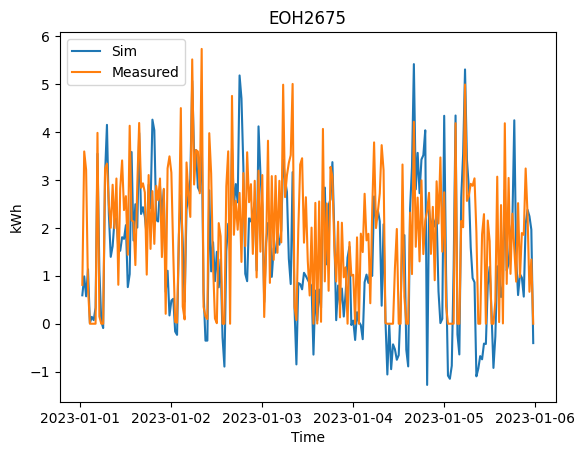

In [60]:
# ------- Look at heat supply performance in validation data ------

df_id = trained_params[id_use].copy()
C = df_id.C
R_a = df_id.R_a
R_m = df_id.R_m
w_s= df_id.w_s
w = df_id.w


df_single = df_train_detached[df_train_detached["Property_ID"] == id_use].copy()

#re-adjust Heat Pump Diff and add temp differences
df_single["Heat_Pump_Energy_Output_Diff"] = df_single["Heat_Pump_Energy_Output"].diff()
df_single["Internal_Temperature_Diff"] = df_single["Internal_Air_Temperature"].diff()
df_single["Internal_Ambient_Temperature_Diff"] = \
    (df_single["External_Air_Temperature"] - 
     df_single["Internal_Air_Temperature"])


temps = df_single["Internal_Air_Temperature"]

# trailing moving average (includes the current step + the previous window_steps−1)
df_single["Mass_Temperature"] = (
    temps
    .rolling(window=window_steps, min_periods=window_steps)  # require full window
    .mean()
)


# 1. Drop columns with almost all missing data (e.g., more than 90% missing)
threshold = 0.90 * len(df_single)
df_single_cleaned = df_single.dropna(axis=1, thresh=threshold)
#print("Columns dropped due to high missing values:")
#print(df_single.columns.difference(df_single_cleaned.columns).tolist())

df_single = df_single_cleaned

#print("\nColumns remaining after dropping highly missing columns:")
#print(df_single.columns.tolist())

# 2. Handle missing values: Interpolate if missing for up to 2 hours (4 half-hour intervals), else drop rows
df_single = df_single.set_index('Timestamp')
df_single = df_single.sort_index()

# Apply interpolation with a limit of 4 (for 2 hours of half-hourly data)
numeric_cols = df_single.select_dtypes(include=['number']).columns
df_single_numeric_interpolated = df_single[numeric_cols].interpolate(method='time', limit=4, limit_direction='both')

df_single_interpolated = df_single.copy() 
df_single_interpolated[numeric_cols] = df_single_numeric_interpolated

# After interpolation, drop rows that still contain NaN values (meaning they were missing for > 2 hours)
initial_rows = len(df_single_interpolated)
df_single_processed = df_single_interpolated.dropna()
rows_dropped_after_interpolation = initial_rows - len(df_single_processed)

#print(f"\nNumber of rows dropped after handling NA values (missing for >
# 2 hours): {rows_dropped_after_interpolation}")

# -----EXTRACT SUMMER DATA -------# 
df_heating_single = df_single_processed.copy()

t_start = pd.to_datetime("2023 01 01 00:00:00")
t_end = pd.to_datetime("2023 01 05 23:59:00")
df_q_opt = df_q_results[(df_q_results.index>=t_start) & (df_q_results.index<=t_end)]
df_heating_val = df_heating_single[df_heating_single.index>=t_start]
df_heating_val = df_heating_val[df_heating_val.index<=t_end]



T_a_val = (df_heating_val["External_Air_Temperature"].iloc[:-1].reset_index
       (drop=True).to_numpy()) 
T_i_val = (df_heating_val["Internal_Air_Temperature"].iloc[:-1].reset_index
       (drop=True).to_numpy()) 
delta_T_a_val = (df_heating_val["Internal_Ambient_Temperature_Diff"].iloc[:-1]
             .reset_index(drop=True).to_numpy()) 
delta_T_i_val = (df_heating_val["Internal_Temperature_Diff"].iloc[1:]
             .reset_index(drop=True).to_numpy() / delta_t) 
delta_T_i_m_val = (df_heating_val["Mass_Temperature"].iloc[:-1]
             .reset_index(drop=True).to_numpy()-T_i_val)
q_hp_val = (df_heating_val["Heat_Pump_Energy_Output_Diff"].iloc[:-1]
        .reset_index(drop=True).to_numpy()) 
q_solar_val = (df_heating_val["SolarRadiation"].iloc[:-1].reset_index
           (drop=True).to_numpy()) 
v_wind_val = (df_heating_val["Windspeed"].iloc[:-1].reset_index(drop=True)
          .to_numpy()) 



q_hat_sim = (delta_T_i_val * C -  delta_T_a_val / R_a * delta_t 
             - delta_T_i_m_val / R_m * delta_t - w_s *  q_solar_val  
             - w * np.ones(len(T_a_val), )* delta_t )

e_q = q_hat_sim - q_hp_val
rmse_q_val = np.sqrt(np.mean(e_q**2))
print(f"RMSE of q_hp: {rmse_q_val}")

plt.plot(df_heating_val.index[1:],q_hat_sim, label = "Sim")
plt.plot(df_heating_val.index[1:], q_hp_val, label = "Measured")
plt.legend()
plt.xlabel("Time")
plt.ylabel("kWh")
plt.title(f"{id_use}")
plt.show()

In [61]:
df_heating_single

,Property_ID,half-hour,Circulation_Pump_Energy_Consumed,Heat_Pump_Energy_Output,Whole_System_Energy_Consumed,External_Air_Temperature,Heat_Pump_Heating_Flow_Temperature,Heat_Pump_Return_Temperature,Internal_Air_Temperature,Hot_Water_Flow_Temperature,...,FeelsLike,Humidity,Dew,Precipitation,SolarRadiation,SolarEnergy,Windspeed,Internal_Temperature_Diff,Internal_Ambient_Temperature_Diff,Mass_Temperature
Timestamp,,,,,,,,,,,,,,,,,,,,,
2020-11-12 18:00:00,EOH2675,18:00:00,0.000,15.836,4.399,10.57,41.03,39.29,19.81,43.08,...,7.20,84.570,6.70,0.0000,0.0,0.0,13.30,-0.06,-9.24,18.321333
2020-11-12 18:30:00,EOH2675,18:30:00,0.000,19.312,5.252,10.72,41.71,37.40,19.67,43.08,...,8.65,80.725,6.45,0.0000,0.0,0.0,13.45,-0.14,-8.95,18.321333
2020-11-12 19:00:00,EOH2675,19:00:00,0.000,20.699,5.619,10.89,34.28,33.28,19.82,43.08,...,10.10,76.880,6.20,0.0000,0.0,0.0,13.60,0.15,-8.93,18.321333
2020-11-12 19:30:00,EOH2675,19:30:00,0.000,20.699,5.627,11.09,29.48,29.12,19.83,43.08,...,10.05,79.620,6.70,0.0000,0.0,0.0,11.80,0.01,-8.74,18.321333
2020-11-12 20:00:00,EOH2675,20:00:00,0.000,23.512,6.262,11.29,34.30,31.47,19.75,43.08,...,10.00,82.360,7.20,0.0000,0.0,0.0,10.00,-0.08,-8.46,18.321333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-28 22:00:00,EOH2675,22:00:00,212.928,59675.471,19247.864,13.39,14.86,15.03,15.72,56.66,...,14.00,82.040,11.00,0.0110,0.0,0.0,25.40,-0.03,-2.33,15.772000
2023-09-28 22:30:00,EOH2675,22:30:00,212.928,59675.471,19247.872,13.08,14.86,14.98,15.68,56.66,...,14.00,82.225,11.00,0.0400,0.0,0.0,24.70,-0.04,-2.60,15.765333
2023-09-28 23:00:00,EOH2675,23:00:00,212.928,59675.471,19247.879,12.77,14.86,14.94,15.68,56.66,...,14.00,82.410,11.00,0.0690,0.0,0.0,24.00,0.00,-2.91,15.756667


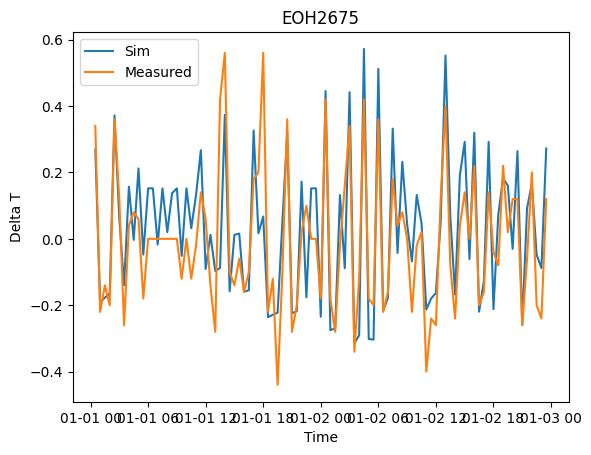

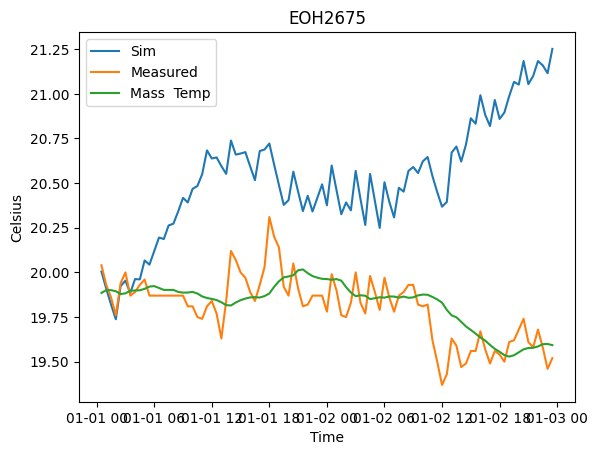

In [62]:
# -----Look at temperature tracking performance in the training --------------

df_id = trained_params[id_use].copy()
C = df_id.C
R_a = df_id.R_a
w_s= df_id.w_s
w = df_id.w

df_single = df_train_detached[df_train_detached["Property_ID"] == id_use].copy()

#re-adjust Heat Pump Diff and add temp differences
df_single["Heat_Pump_Energy_Output_Diff"] = df_single["Heat_Pump_Energy_Output"].diff()
df_single["Internal_Temperature_Diff"] = df_single["Internal_Air_Temperature"].diff()
df_single["Internal_Ambient_Temperature_Diff"] = \
    (df_single["External_Air_Temperature"] - 
     df_single["Internal_Air_Temperature"])


# trailing moving average (includes the current step + the previous window_steps−1)
df_single["Mass_Temperature"] = (
    temps
    .rolling(window=window_steps, min_periods=window_steps)  # require full window
    .mean()
)
     


# 1. Drop columns with almost all missing data (e.g., more than 90% missing)
threshold = 0.90 * len(df_single)
df_single_cleaned = df_single.dropna(axis=1, thresh=threshold)
#print("Columns dropped due to high missing values:")
#print(df_single.columns.difference(df_single_cleaned.columns).tolist())

df_single = df_single_cleaned

#print("\nColumns remaining after dropping highly missing columns:")
#print(df_single.columns.tolist())

# 2. Handle missing values: Interpolate if missing for up to 2 hours (4 half-hour intervals), else drop rows
df_single = df_single.set_index('Timestamp')
df_single = df_single.sort_index()

# Apply interpolation with a limit of 4 (for 2 hours of half-hourly data)
numeric_cols = df_single.select_dtypes(include=['number']).columns
df_single_numeric_interpolated = df_single[numeric_cols].interpolate(method='time', limit=4, limit_direction='both')

df_single_interpolated = df_single.copy() 
df_single_interpolated[numeric_cols] = df_single_numeric_interpolated

# After interpolation, drop rows that still contain NaN values (meaning they were missing for > 2 hours)
initial_rows = len(df_single_interpolated)
df_single_processed = df_single_interpolated.dropna()
rows_dropped_after_interpolation = initial_rows - len(df_single_processed)

#print(f"\nNumber of rows dropped after handling NA values (missing for >
# 2 hours): {rows_dropped_after_interpolation}")

# -----EXTRACT SUMMER DATA -------# 
df_heating_single = df_single_processed.copy()

# Validate results
t_start = pd.to_datetime("2022 01 01 00:00:00")
t_end = pd.to_datetime("2022 01 02 23:59:00")
df_q_id_use = df_q_id[(df_q_id.index>=t_start) & (df_q_id.index<=t_end)]
df_heating_val = df_heating_single[df_heating_single.index>=t_start]
df_heating_val = df_heating_val[df_heating_val.index<=t_end]



T_a_val = (df_heating_val["External_Air_Temperature"].iloc[:-1].reset_index
       (drop=True).to_numpy()) 
T_i_val = (df_heating_val["Internal_Air_Temperature"].iloc[:-1].reset_index
       (drop=True).to_numpy()) 
delta_T_a_val = (df_heating_val["Internal_Ambient_Temperature_Diff"].iloc[:-1]
             .reset_index(drop=True).to_numpy()) 
delta_T_i_val = (df_heating_val["Internal_Temperature_Diff"].iloc[1:]
             .reset_index(drop=True).to_numpy() / delta_t) 
delta_T_i_m_val = (df_heating_val["Mass_Temperature"].iloc[:-1]
             .reset_index(drop=True).to_numpy()-T_i_val)
q_hp_val = (df_heating_val["Heat_Pump_Energy_Output_Diff"].iloc[:-1]
        .reset_index(drop=True).to_numpy()) 
q_opt = df_q_id_use[id_use].iloc[:-1].reset_index(drop=True).to_numpy()
q_solar_val = (df_heating_val["SolarRadiation"].iloc[:-1].reset_index
           (drop=True).to_numpy()) 
v_wind_val = (df_heating_val["Windspeed"].iloc[:-1].reset_index(drop=True)
          .to_numpy()) 


delta_T_i_sim = (delta_T_a_val / R_a *delta_t + delta_T_i_m_val / R_m *delta_t
                 + q_opt + w_s* q_solar_val + w
                 * np.ones(len(T_a_val), )* delta_t) / C

T_i_sim = np.zeros_like(T_i_val)
T_i_prev = T_i_val[0]
for i in range(len(delta_T_i_sim)):
    T_i_sim[i] = T_i_prev + delta_T_i_sim[i]*delta_t
    T_i_prev = T_i_sim[i]


plt.plot(df_heating_val.index[1:],delta_T_i_sim, label = "Sim")
plt.plot(df_heating_val.index[1:], delta_T_i_val, label = "Measured")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Delta T")
plt.title(f"{id_use}")
plt.show()

plt.plot(df_heating_val.index[1:],T_i_sim, label = "Sim")
plt.plot(df_heating_val.index[1:], df_heating_val["Internal_Air_Temperature"]
         .iloc[1:].reset_index
       (drop=True).to_numpy(), label = "Measured")
plt.plot(df_heating_val.index[1:],df_heating_val["Mass_Temperature"].iloc[:-1], label = "Mass  Temp")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Celsius")
plt.title(f"{id_use}")
plt.show()